In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv('/content/consumer_electronics_sales_data.csv')
df

,ProductID,ProductCategory,ProductBrand,ProductPrice,CustomerAge,CustomerGender,PurchaseFrequency,CustomerSatisfaction,PurchaseIntent
0,5874,Smartphones,Other Brands,312.949668,18,0,2,1,0
1,5875,Smart Watches,Samsung,980.389404,35,1,7,2,1
2,5876,Tablets,Samsung,2606.718293,63,0,1,5,1
3,5877,Smartphones,Samsung,870.395450,63,1,10,3,1
4,5878,Tablets,Sony,1798.955875,57,0,17,3,0
...,...,...,...,...,...,...,...,...,...
8995,14869,Smart Watches,Samsung,1041.149163,36,1,16,4,0
8996,14870,Smartphones,Samsung,1485.694311,57,0,5,1,1
8997,14871,Headphones,Samsung,2887.369597,28,0,18,4,0
8998,14872,Tablets,HP,1490.453964,38,0,4,2,1


In [5]:
df.dtypes

,0
ProductID,int64
ProductCategory,object
ProductBrand,object
ProductPrice,float64
CustomerAge,int64
CustomerGender,int64
PurchaseFrequency,int64
CustomerSatisfaction,int64
PurchaseIntent,int64


In [6]:
df.isna().sum()

,0
ProductID,0
ProductCategory,0
ProductBrand,0
ProductPrice,0
CustomerAge,0
CustomerGender,0
PurchaseFrequency,0
CustomerSatisfaction,0
PurchaseIntent,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9000 entries, 0 to 8999
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductID             9000 non-null   int64  
 1   ProductCategory       9000 non-null   object 
 2   ProductBrand          9000 non-null   object 
 3   ProductPrice          9000 non-null   float64
 4   CustomerAge           9000 non-null   int64  
 5   CustomerGender        9000 non-null   int64  
 6   PurchaseFrequency     9000 non-null   int64  
 7   CustomerSatisfaction  9000 non-null   int64  
 8   PurchaseIntent        9000 non-null   int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 632.9+ KB


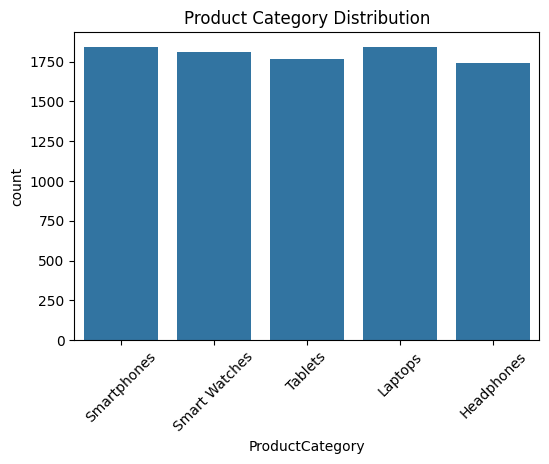

In [14]:
plt.figure(figsize=(6,4))
sns.countplot(x='ProductCategory', data=df)
plt.title("Product Category Distribution")
plt.xticks(rotation=45)
plt.show()

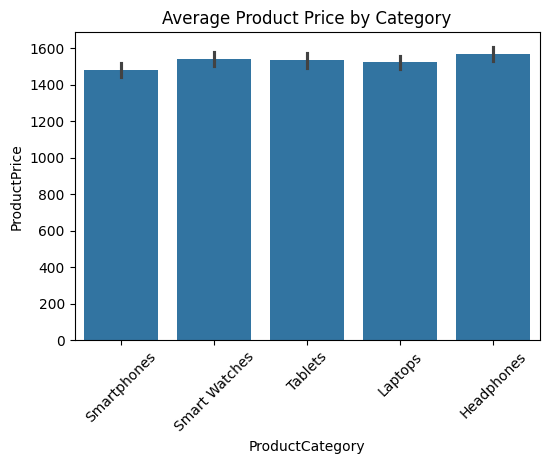

In [15]:
plt.figure(figsize=(6,4))
sns.barplot(x='ProductCategory', y='ProductPrice', data=df)
plt.title("Average Product Price by Category")
plt.xticks(rotation=45)
plt.show()

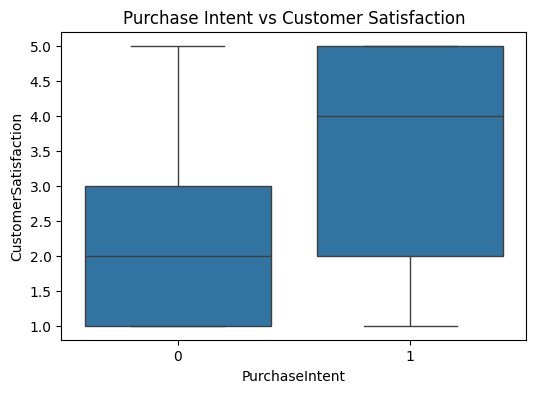

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='PurchaseIntent', y='CustomerSatisfaction', data=df)
plt.title("Purchase Intent vs Customer Satisfaction")
plt.show()

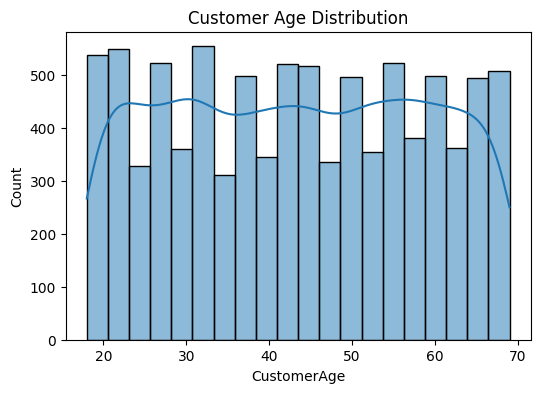

In [17]:
plt.figure(figsize=(6,4))
sns.histplot(df['CustomerAge'], bins=20, kde=True)
plt.title("Customer Age Distribution")
plt.show()

In [18]:
df_encoded = pd.get_dummies(df, columns=['ProductCategory', 'ProductBrand'], drop_first=True)


In [19]:
X = df_encoded.drop(['PurchaseIntent', 'ProductID'], axis=1)
y = df_encoded['PurchaseIntent']

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [22]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))


Accuracy: 0.8522222222222222
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       793
           1       0.86      0.88      0.87      1007

    accuracy                           0.85      1800
   macro avg       0.85      0.85      0.85      1800
weighted avg       0.85      0.85      0.85      1800



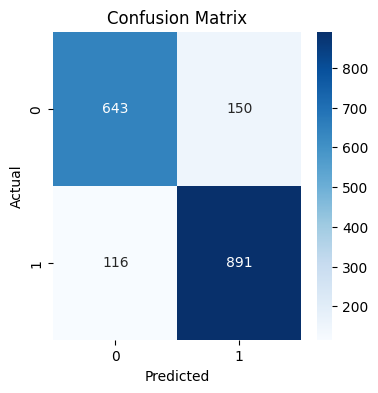

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
